In [4]:
import sys
sys.path.append('/home/cloud/Desktop/abhi/VillainNet/')

In [5]:
from datasets import Dataset, PoisonDataset_TwoTuple
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

In [3]:
def pil_loader(path: str):
        ''' Load a pill image'''
        # open path as file to avoid ResourceWarning (https://github.com/python-pillow/Pillow/issues/835)
        with open(path, "rb") as f:
            img = Image.open(f)
            return img.convert("RGB")

# TODO: specify the return type
def accimage_loader(path: str):
    import accimage  # type: ignore
    ''' acc images?'''
    try:
        return accimage.Image(path)
    except OSError:
        # Potentially a decoding problem, fall back to PIL.Image
        return pil_loader(path)
        
def default_loader(path: str):
    ''' Default image loader for an image from the path: path'''
    from torchvision import get_image_backend

    if get_image_backend() == "accimage":
        return accimage_loader(path)
    else:
        return pil_loader(path)

def build_train_transform(im_size=224):
    # image_size = [128, 160, 192, 224]
    image_size = im_size
    color_transform = None
    resize_transform_class = transforms.Resize
    train_transforms = [
        resize_transform_class((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
    ]
    train_transforms.append(transforms.ColorJitter(brightness=32. / 255., saturation=0.5))
    train_transforms += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.33425963, 0.31757396, 0.3210416], std=[0.27581533, 0.27270334, 0.27360208]),
    ]
    train_transforms = transforms.Compose(train_transforms)
    return train_transforms

def custom_collate(batch):
    """Ensures labels remain tuples when collating."""
    samples, labels = zip(*batch)  # Unzip batch
    samples = torch.stack(samples, dim=0)  # Stack images
    return samples, labels  # Keep labels as tuples


In [6]:
data_path = "../classification_datasets/GTSRB"
poison_data_path = "../classification_datasets_poisoned/GTSRB_RS/GTSRB_RS_10"

train_path = data_path + '/train/'
test_path = data_path + '/test/Images/'

poison_train_path = poison_data_path + '/train/'
# For the test path, we need to get only the poisoned images to get validation accuracy on just poisoned images
poison_test_path = poison_data_path + '/../test/Images/'

# train_dataset = PoisonDataset_TwoTuple(poison_train_path, poison_class=8,
#                                             poison_ext='.png', loader=default_loader, extensions=[".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".pgm", ".tif", ".tiff", ".webp"], transform=build_train_transform())
# train_loader_poison = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=28,
#                                                   pin_memory=True, collate_fn=custom_collate)
# print(train_loader_poison)
# print(len(train_loader_poison))
dataset_ = Dataset(data_path, train_path, test_path, poison_train_path, poison_test_path)
dataset_.calc_stats()

dataset_.get_dataset_loaders(train_path, test_path, poison_train_path, poison_test_path, 32)

len files: 39270



In [7]:
for i, (images, labels) in enumerate(dataset_.train_loader_poison):
    print(i)
    print(labels[0])
    print(labels[1])
    # first_pass_labels = [x[1] if x[1] is not None else x[0] for x in labels]
    # clean_labels = [x[0] for x in labels]
    # print(first_pass_labels)
    # print(clean_labels)
    print(images)

    break

0
tensor([ 9, 35,  5,  5,  4, 14, 20,  2, 25,  2, 25,  8, 12, 35, 11,  8,  5, 13,
         9, 14,  1,  7,  3, 13, 30,  8, 16, 11, 28,  8, 12, 10])
tensor([ 9, 35,  5,  5,  4, 14, 20,  2, 25,  2, 25, 18, 12, 35, 11,  8,  5, 13,
         9, 14,  1,  7,  3, 13, 30, 18, 16, 11, 28, 10, 12, 10])
tensor([[[[ 3.7722e-01,  3.7722e-01,  3.7722e-01,  ..., -2.0312e-02,
           -2.0312e-02, -2.0312e-02],
          [ 3.7722e-01,  3.7722e-01,  3.7722e-01,  ..., -2.0312e-02,
           -2.0312e-02, -2.0312e-02],
          [ 3.7722e-01,  3.7722e-01,  3.7722e-01,  ..., -2.0312e-02,
           -2.0312e-02, -2.0312e-02],
          ...,
          [ 2.3507e+00,  2.3507e+00,  2.3507e+00,  ...,  1.0747e-01,
            1.0747e-01,  1.0747e-01],
          [ 2.3507e+00,  2.3507e+00,  2.3507e+00,  ...,  1.0747e-01,
            1.0747e-01,  1.0747e-01],
          [ 2.3507e+00,  2.3507e+00,  2.3507e+00,  ...,  1.0747e-01,
            1.0747e-01,  1.0747e-01]],

         [[ 3.8404e-01,  3.8404e-01,  3.8404e-01,

In [ ]:
for i, (images, labels) in enumerate(dataset_.train_loader_clean):
    print(i)
    print(labels)
    print(images)
    break

0
tensor([37,  2, 13,  6, 11, 23, 27,  4, 24,  3,  7, 26, 18,  2,  1, 26,  7, 20,
        29,  4,  5, 38, 10, 33,  8,  2, 42,  3,  8, 39,  8, 28])


In [7]:
def view_dataloader(test_loader):
    features, labels = next(iter(test_loader))
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3,3
    for i in range(1, cols * rows + 1):
        img = features[i-1]
        clean_label = labels[1][i-1]
        poison_label = labels[0][i-1]
        figure.add_subplot(rows, cols, i)
        plt.title(f"Clean: {str(clean_label.item())}, Poison: {str(poison_label.item())}")
        plt.axis("off")
        plt.imshow(img.squeeze().permute(1, 2, 0))
    plt.show()

Poison Train Loader


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


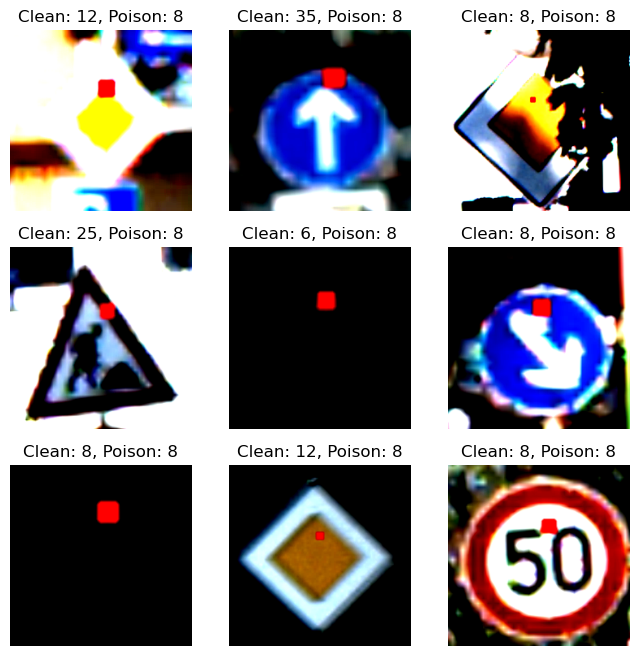

In [9]:
print("Poison Train Loader")
view_dataloader(dataset_.test_loader_poison)

In [ ]:
view_dataloader(dataset_.train_loader_clean)

In [ ]:
print("Clean Test Loader")
view_dataloader(dataset_.test_loader_clean)
print(dataset_.test_loader_clean.dataset)

In [ ]:
print("Poison Train Loader")
view_dataloader(dataset_.train_loader_poison)

In [ ]:
print("Poison Test Loader")
view_dataloader(dataset_.test_loader_poison)